<a href="https://colab.research.google.com/github/iamatulkumar-ya/data-science/blob/master/libraries/langchain/langgraph/langgraph_persistence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangGraph Persistence

LangGraph Persistence: <i>LangGraph has a built-in persistence layer, implemented through checkpointers. When you compile a graph with a checkpointer, the checkpointer saves a checkpoint of the graph state at every super-step. Those checkpoints are saved to a thread, which can be accessed after graph execution. Because threads allow access to graph's state after execution, several powerful capabilities including human-in-the-loop, memory, time travel, and fault-tolerance are all possible. </i>

Documents:


*   https://docs.langchain.com/oss/python/langgraph/quickstart
*   https://docs.langchain.com/oss/python/langgraph/graph-api
*   https://docs.langchain.com/oss/python/langgraph/persistence



In simple words, persistence helps us to save the state for the workflow. It helps to resume from failed workflow, or rerun the completed workflow etc.

In [18]:
%%capture
!pip install langgraph
!pip install mermaid-py  # to visualise the graph

In [20]:
# defining grpah
# Stategraph is used to typed the output and share the state vars across multiple nodes
from langgraph.graph import StateGraph, END
# Using below lib for graph structure to visualize
import mermaid as md
# Below is the lib to render the image
from IPython.display import Image
from typing import Annotated, TypedDict
from IPython.core.compilerop import operator

In [76]:
# state class for graph state
class AgentState(TypedDict):
  messages: Annotated[list, operator.add] # declared the dict with annotated that each item get added as arrives

Creating functions to act as a node functionality

In [77]:
def first_node(state:AgentState):
  return  {"messages": ["first node response."]}

def second_node(state:AgentState):
  return {"messages": ["Adding second node response."]}

def third_node(state:AgentState):
  return  {"messages": ["Adding third node response."]}

In [78]:
workflow = StateGraph(AgentState)  # we must set schema, if we do not have any then we can set to dict

adding nodes

In [79]:
workflow.add_node("first_node", first_node)
workflow.add_node("second_node", second_node)
workflow.add_node("third_node", second_node)

Creating edges, to connect two nodes

In [80]:
workflow.add_edge("first_node", "second_node")
workflow.add_edge("second_node", "third_node")
workflow.add_edge("third_node", END)

Setting entry point and finish point for the graph

In [81]:
workflow.set_entry_point("first_node")

Let's compile with persistence and invoke

### InMemory Persistence

In [46]:
from langgraph.checkpoint.memory import InMemorySaver

<b>Checkpoint: </b> Checkpoints are simply checkpoints which get created as graph executes to store the state value.

In [106]:
# creating object for inmemorysaver to store the state value
memoryObj = InMemorySaver()

In [107]:
# now adding the checkpointer as memoryObj to store the graph states
app = workflow.compile(checkpointer=memoryObj)

let's view the graph structure

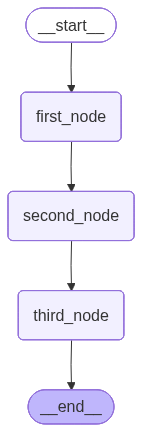

In [73]:
display(Image(app.get_graph().draw_mermaid_png()))

In [108]:
input_text = {"messages": ["Tell me about langgraph persistence."]}

# now, before invoking, we must initialize the thread_id, which will be used to uniquely identify the execution
threadConfig = {"configurable": {"thread_id":"1"}}


<b>Threads: </b> So, threads are used to uniquely identify the graph execution. If we want to resume the executed graph, then we have to use thread_id of the previously executed graph.

In [109]:

output_text = app.invoke(input_text, threadConfig)

In [110]:
print(output_text)

{'messages': ['Tell me about langgraph persistence.', 'first node response.', 'Adding second node response.', 'Adding second node response.']}


nice, let's see the state

In [111]:
app.get_state(threadConfig)

StateSnapshot(values={'messages': ['Tell me about langgraph persistence.', 'first node response.', 'Adding second node response.', 'Adding second node response.']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0bef51-39ae-6510-8003-7d88cb2610db'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-11-11T11:53:45.366845+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0bef51-39ac-62a6-8002-db4c1ca9b392'}}, tasks=(), interrupts=())

In [116]:
list(app.get_state_history(threadConfig))

[StateSnapshot(values={'messages': ['Tell me about langgraph persistence.', 'first node response.', 'Adding second node response.', 'Adding second node response.']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0bef51-39ae-6510-8003-7d88cb2610db'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-11-11T11:53:45.366845+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0bef51-39ac-62a6-8002-db4c1ca9b392'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'messages': ['Tell me about langgraph persistence.', 'first node response.', 'Adding second node response.']}, next=('third_node',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0bef51-39ac-62a6-8002-db4c1ca9b392'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-11-11T11:53:45.365962+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_n

Now, grpah has executed successfully, but still we can consume the state due to InMemory persistence. Let's execute another thread.

In [112]:
input_text2 = {"messages": ["Tell me about langgraph state."]}

# now, before invoking, we must initialize the thread_id, which will be used to uniquely identify the execution
threadConfig2 = {"configurable": {"thread_id":"2"}}

output_text2 = app.invoke(input_text2, threadConfig2)
print(output_text2)


{'messages': ['Tell me about langgraph state.', 'first node response.', 'Adding second node response.', 'Adding second node response.']}
StateSnapshot(values={'messages': ['Tell me about langgraph state.', 'first node response.', 'Adding second node response.', 'Adding second node response.']}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bef51-735b-6fb4-8003-f9c2e31e41bd'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-11-11T11:53:51.414856+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bef51-7359-6796-8002-7a89f39bc92b'}}, tasks=(), interrupts=())


In [113]:
app.get_state(threadConfig2)

StateSnapshot(values={'messages': ['Tell me about langgraph state.', 'first node response.', 'Adding second node response.', 'Adding second node response.']}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bef51-735b-6fb4-8003-f9c2e31e41bd'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-11-11T11:53:51.414856+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bef51-7359-6796-8002-7a89f39bc92b'}}, tasks=(), interrupts=())

In [115]:
list(app.get_state_history(threadConfig2))

[StateSnapshot(values={'messages': ['Tell me about langgraph state.', 'first node response.', 'Adding second node response.', 'Adding second node response.']}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bef51-735b-6fb4-8003-f9c2e31e41bd'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-11-11T11:53:51.414856+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bef51-7359-6796-8002-7a89f39bc92b'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'messages': ['Tell me about langgraph state.', 'first node response.', 'Adding second node response.']}, next=('third_node',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0bef51-7359-6796-8002-7a89f39bc92b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-11-11T11:53:51.413826+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'che

In [ ]:

output_text = app.invoke(input_text, threadConfig)# # creating various functions which will represent the nodes
# import random
# def agent_node(agentState: AgentState):
#   # here we can fetch the current state of the flow to make decisions
#   print("\nInside Agent Node ", agentState)
#   nextCall = "RAG" if (random.randint(1,9))%2 == 0 else "LLM"
#   return {'messages' : [f"Agent call completed. Proceed with {nextCall}"]}


# def rag_node(agentState: AgentState):
#   # here we can fetch the current state of the flow to make decisions
#   print("\nInside RAG Node ", agentState)
#   return {'messages' : ['This is the RAG response. RAG call completed']}


# def llm_node(agentState: AgentState):
#   # here we can fetch the current state of the flow to make decisions
#   print("\nInside LLM Node ", agentState)
#   return {'messages' : ['This is LLM response. LLM call completed']}

In [ ]:
# # defining the router

# def router(agentState: AgentState):
#   # let's fetch the recent message such that we can decide the route for next flow
#   message = str(agentState["messages"][-1])

#   if message.__contains__("RAG"):
#     return "RAG Call"
#   else:
#     return "LLM Call"

In [ ]:
# # defining the graph and adding nodes and edges

# cGraph = StateGraph(AgentState)

# cGraph.add_node("agent", agent_node)
# cGraph.add_node("rag", rag_node)
# cGraph.add_node("llm", llm_node)


In [ ]:
# # now adding conditional edge and rest adges

# cGraph.add_conditional_edges(
#     "agent",
#     router,
#     {
#         "RAG Call" : "rag",
#         "LLM Call" : "llm"
#     }
# )


# # let's end the flow once either rag or llm gets executed
# cGraph.add_edge("rag", END)
# cGraph.add_edge("llm", END)